# Part 3.3 Final Kaggle Model Interpretability

Notebook này tập trung vào **final submission line** của repo: `meta_horizon_nnls`.

Mục tiêu của notebook:

- rebuild trực tiếp final meta model từ code,
- xác nhận rõ model nào là internal CV winner, model nào là line nộp cuối,
- trực quan hóa **meta weights theo horizon**,
- trực quan hóa **SHAP** của các specialist quan trọng,
- để lại phần **diễn giải tiếng Việt** bám sát insight của project.


In [1]:
%matplotlib inline

from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / "models").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.final_meta_regime_ensemble import build_final_meta_regime_ensemble

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

SEGMENT_ORDER = ['global', 'early', 'mid', 'mid_early', 'mid_late', 'late', '2019', '2020', '2021', '2022', 'normal', 'sale_window', 'odd_august']

def ordered_columns(cols):
    head = [c for c in SEGMENT_ORDER if c in cols]
    tail = [c for c in cols if c not in head]
    return head + tail


def plot_weight_heatmap(weights: pd.DataFrame, target: str, ax: plt.Axes, title: str):
    frame = weights[(weights['target'] == target) & (weights['component'] != 'intercept')].copy()
    pivot = frame.pivot_table(index='component', columns='segment', values='weight', aggfunc='first').fillna(0.0)
    pivot = pivot.reindex(columns=ordered_columns(list(pivot.columns)))
    sns.heatmap(pivot, cmap='RdBu_r', center=0.0, annot=True, fmt='.2f', cbar=True, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Segment')
    ax.set_ylabel('Component')


def plot_shap_summary(summary: pd.DataFrame, ax: plt.Axes, title: str, color: str):
    top = summary.head(10).iloc[::-1]
    ax.barh(top['feature'], top['mean_abs_shap'], color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Mean |SHAP|')
    ax.set_ylabel('')


In [2]:
outputs = build_final_meta_regime_ensemble()

config = outputs['selected_config']
candidate_table = outputs['candidate_table'].copy()
final_weights = outputs['final_weights_table'].copy()
internal_weights = outputs['weights_table'].copy()
revenue_recursive = outputs['explainability']['revenue_recursive'].copy()
revenue_regime = outputs['explainability']['revenue_regime'].copy()
ratio_recursive = outputs['explainability']['ratio_recursive'].copy()
ratio_regime = outputs['explainability']['ratio_regime'].copy()
feature_stability = outputs['explainability']['feature_stability_summary'].copy()

summary_view = candidate_table[[
    'candidate_name', 'joint_objective', 'revenue_r2', 'cogs_r2', 'internal_cv_winner', 'final_submission'
 ]].copy()
summary_view


[meta_model] outer fold 2019: train=2372 days, valid=365 days
[final_model] fitting heads on history through 2018-12-31 (2372 days)


[meta_model] outer fold 2020: train=2737 days, valid=366 days
[final_model] fitting heads on history through 2019-12-31 (2737 days)


[meta_model] outer fold 2021: train=3103 days, valid=365 days
[final_model] fitting heads on history through 2020-12-31 (3103 days)


[meta_model] outer fold 2022: train=3468 days, valid=365 days
[final_model] fitting heads on history through 2021-12-31 (3468 days)


[final_model] fitting heads on history through 2022-12-31 (3833 days)


[final_model] fitting heads on history through 2022-12-31 (3833 days)


,candidate_name,joint_objective,revenue_r2,cogs_r2,internal_cv_winner,final_submission
0,meta_horizon_ridge,1.066080,0.811080,0.772178,1,0
1,meta_static_nnls,2.272910,0.273604,0.415568,0,0
2,meta_horizon_nnls,2.761181,0.027719,0.226229,0,0
3,meta_horizon_regime_nnls,2.774111,0.027719,0.212063,0,0
4,meta_fine_horizon_nnls,2.921709,-0.056330,0.152473,0,1
5,meta_horizon_story_nnls,2.928355,-0.050310,0.142049,0,0


**Diễn giải**

Trong repo này cần phân biệt rõ hai quyết định:

- `meta_horizon_ridge` là **internal CV winner**, tức là model thắng theo thước đo out-of-fold nội bộ.
- `meta_horizon_nnls` là **final submission model**, tức là line nộp cuối cùng lên Kaggle.

Lý do tách hai vai trò này là vì horizon dự báo rất dài và có regime shift mạnh. Internal CV vẫn hữu ích để benchmark, nhưng không đủ để đại diện cho hiệu quả thực tế trên leaderboard. Vì vậy, notebook này chỉ diễn giải sâu cho `meta_horizon_nnls`.


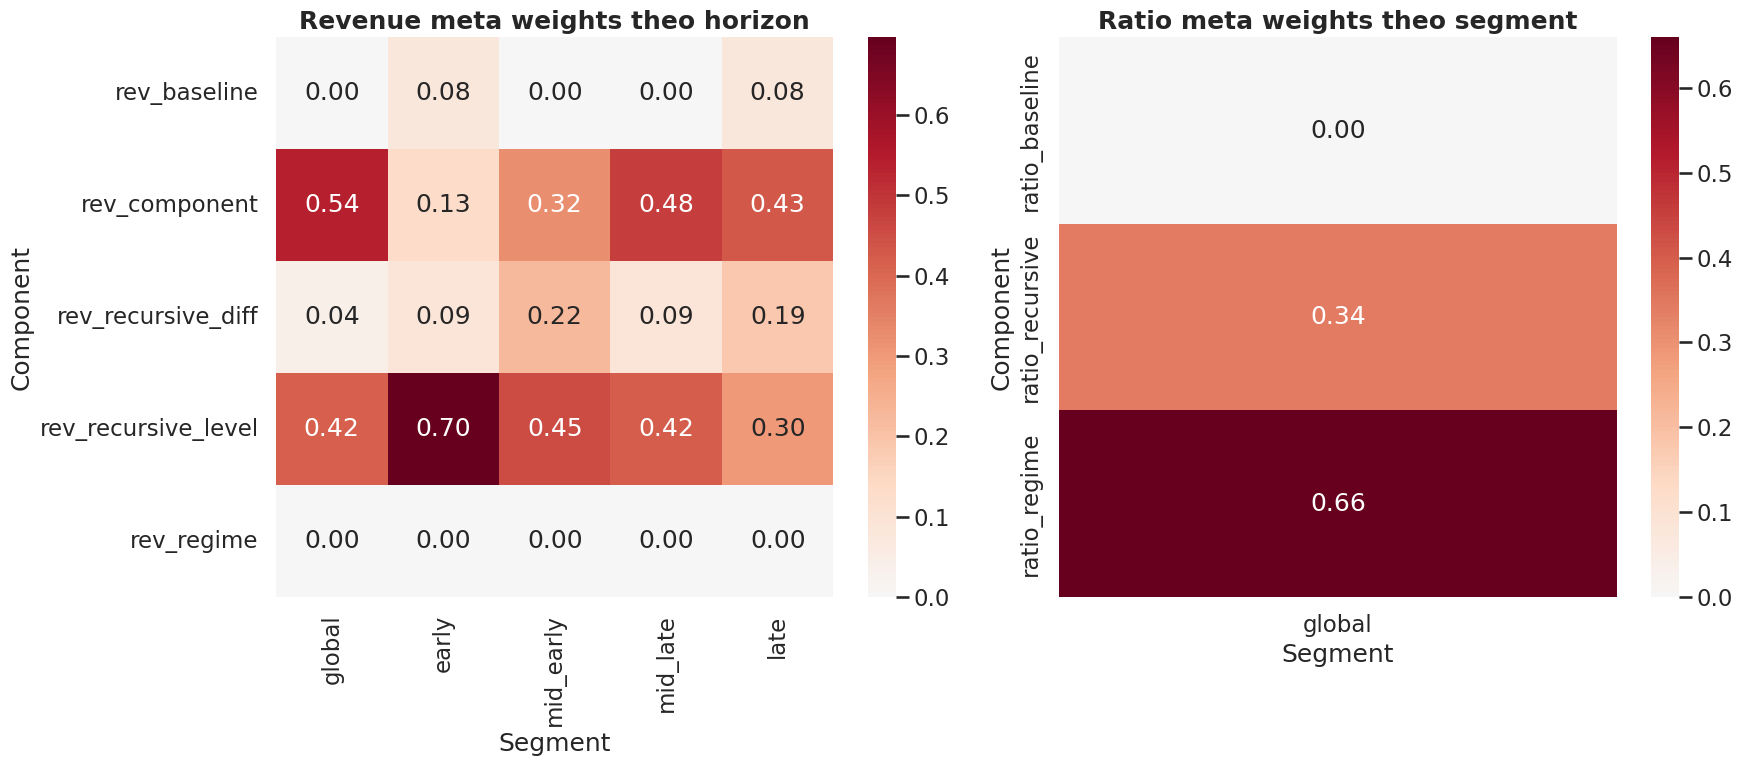

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plot_weight_heatmap(final_weights, 'revenue', axes[0], 'Revenue meta weights theo horizon')
plot_weight_heatmap(final_weights, 'ratio', axes[1], 'Ratio meta weights theo segment')
plt.tight_layout()
display(fig)
plt.close(fig)


**Diễn giải**

Heatmap này là phần quan trọng nhất để hiểu vì sao `meta_horizon_nnls` hợp với final submission hơn một line tĩnh.

- Ở **Revenue**, trọng số không cố định cho toàn bộ 548 ngày mà đổi theo các đoạn `early`, `mid_early`, `mid_late`, `late`.
- Điều đó có nghĩa là mô hình chấp nhận một giả định rất thực tế: **đầu horizon** nên bám chặt hơn vào tín hiệu gần hiện tại, còn **cuối horizon** cần dựa nhiều hơn vào cấu phần dài hạn và regime structure.
- Ở **Ratio/COGS**, tầng blend được giữ ổn định hơn. Đây là lựa chọn hợp lý vì cost ratio thường dễ nhiễu nếu thay weights quá linh hoạt trên horizon dài.

Nếu nhìn theo logic kinh doanh của project, routing này khớp với câu chuyện Part 2: gần thì doanh thu vẫn nhạy với cầu ngắn hạn, nhưng càng đi xa thì ảnh hưởng của inventory health, promo pressure và regime sau 2019 càng phải được phản ánh rõ hơn.


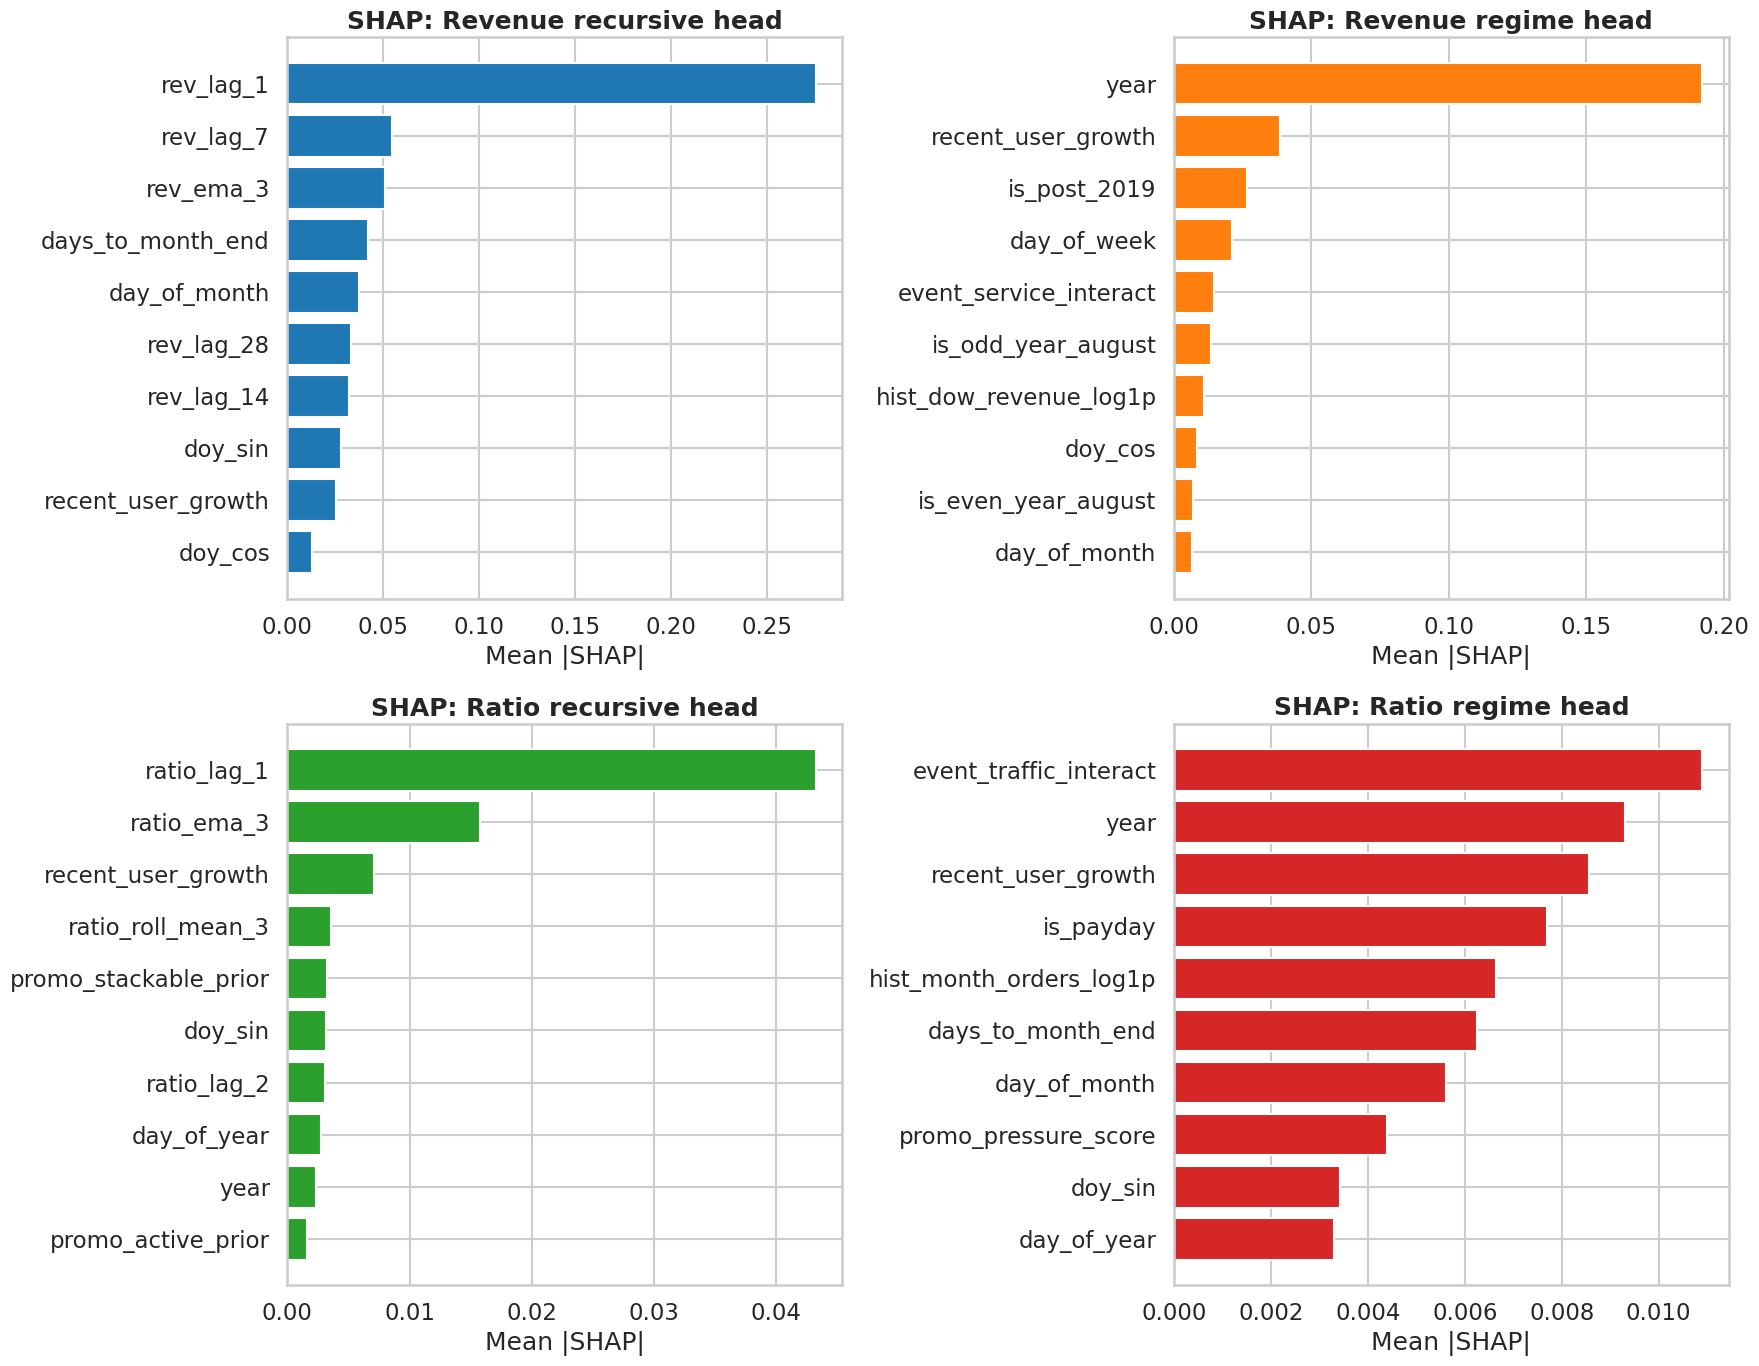

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plot_shap_summary(revenue_recursive, axes[0, 0], 'SHAP: Revenue recursive head', '#1f77b4')
plot_shap_summary(revenue_regime, axes[0, 1], 'SHAP: Revenue regime head', '#ff7f0e')
plot_shap_summary(ratio_recursive, axes[1, 0], 'SHAP: Ratio recursive head', '#2ca02c')
plot_shap_summary(ratio_regime, axes[1, 1], 'SHAP: Ratio regime head', '#d62728')
plt.tight_layout()
display(fig)
plt.close(fig)


**Diễn giải**

Bốn panel SHAP cho thấy final model không phải một black box thuần tuý, mà vẫn tách được thành các cơ chế khá rõ:

1. **Revenue recursive head**
   - Thường bị chi phối bởi `rev_lag_1`, `rev_lag_7`, `rev_ema_3`, `days_to_month_end`, `day_of_month`.
   - Nghĩa là đầu forecast vẫn bám vào nhịp doanh thu rất gần, weekly seasonality và nhịp cầu cận cuối tháng.

2. **Revenue regime head**
   - Các biến như `recent_user_growth`, `year`, `is_post_2019`, `day_of_week` thường nổi bật.
   - Đây là bằng chứng tốt cho luận điểm Part 2: mô hình cần học một **regime chất lượng cầu khác sau 2019**, chứ không chỉ extrapolate từ seasonality cũ.

3. **Ratio recursive head**
   - `ratio_lag_1`, `ratio_ema_3` và một số promo prior là những tín hiệu mạnh nhất.
   - Điều này nói rằng cost ratio ngắn hạn vẫn có quán tính khá cao, nên nếu chi phí vừa xấu đi thì mô hình cũng không giả định nó tự hồi ngay lập tức.

4. **Ratio regime head**
   - `event_traffic_interact`, `days_to_month_end`, `is_payday`, `hist_month_orders_log1p`, `promo_pressure_score` thường có ảnh hưởng rõ.
   - Đây là chỗ câu chuyện kinh doanh đi vào mô hình rõ nhất: cost risk không đến từ promo riêng lẻ, mà đến từ **promo đi sai traffic window** hoặc gặp **inventory regime xấu**.

Nhìn tổng thể, SHAP đang ủng hộ đúng thesis của project: doanh thu và chi phí tương lai được quyết định bởi một chuỗi tương tác giữa demand timing, promo pressure, inventory stress và friction hậu mãi, không phải bởi một seasonal curve đơn giản.


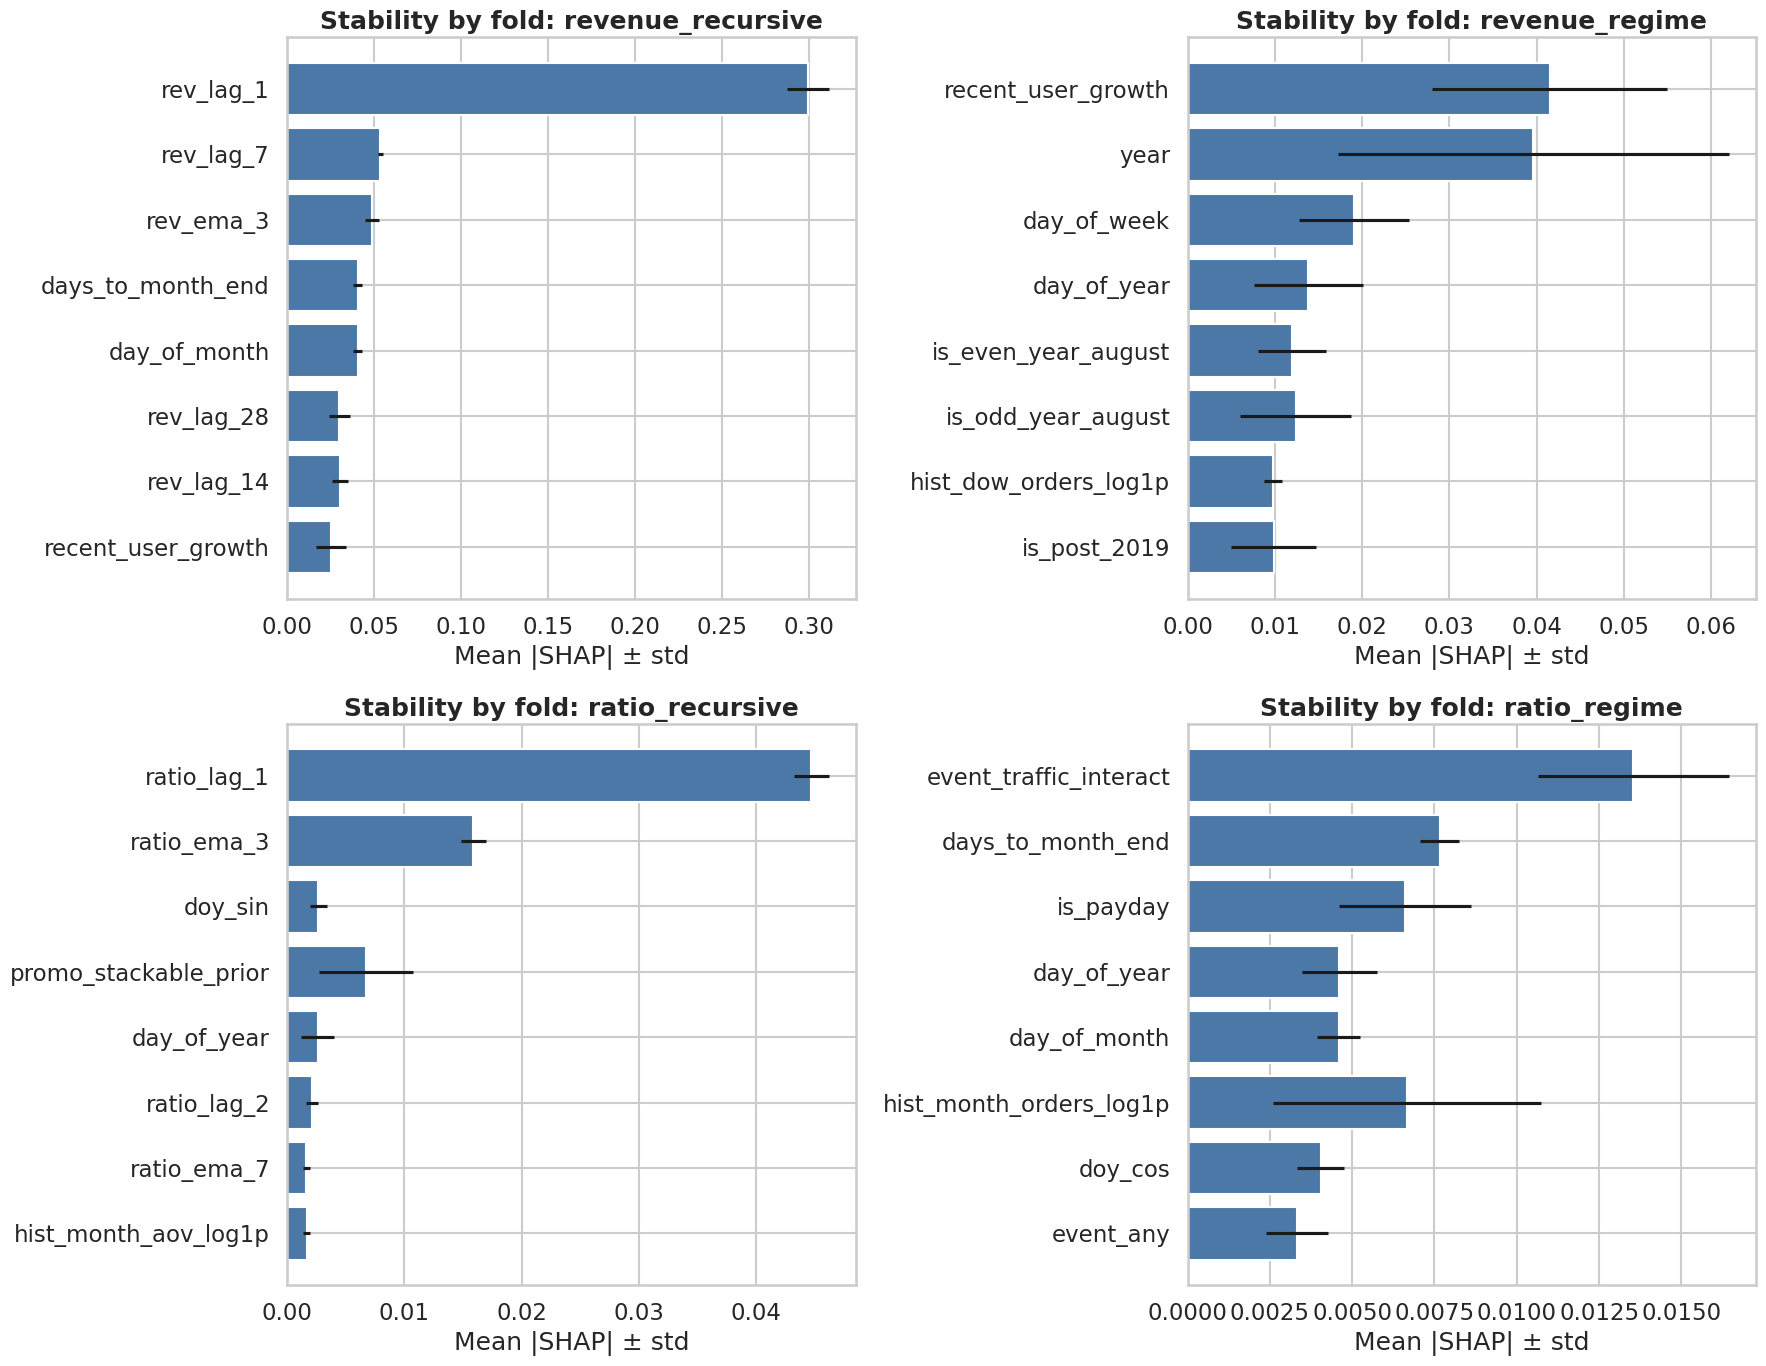

In [5]:
stable = feature_stability.copy()
models_to_plot = ['revenue_recursive', 'revenue_regime', 'ratio_recursive', 'ratio_regime']
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, model_name in zip(axes, models_to_plot):
    top = stable[stable['model'] == model_name].head(8).iloc[::-1]
    ax.barh(top['feature'], top['mean_abs_shap'], xerr=top['std_abs_shap'].fillna(0.0), color='#4c78a8')
    ax.set_title(f'Stability by fold: {model_name}', fontweight='bold')
    ax.set_xlabel('Mean |SHAP| ± std')
    ax.set_ylabel('')

plt.tight_layout()
display(fig)
plt.close(fig)


**Diễn giải**

Biểu đồ stability giúp kiểm tra một rủi ro rất quan trọng: feature nào thực sự ổn định qua các fold, feature nào chỉ nổi lên ở một giai đoạn lịch sử cụ thể.

- Nếu một biến vừa có `mean |SHAP|` cao vừa có `std` thấp, đó là tín hiệu mô hình dùng khá bền vững.
- Nếu một biến có ảnh hưởng trung bình cao nhưng `std` lớn, ta nên xem nó như một feature regime hoặc anomaly detector hơn là một driver ổn định mọi thời điểm.

Với project này, các feature kiểu `rev_lag_1`, `rev_lag_7`, `ratio_lag_1`, `days_to_month_end` thường ổn định hơn. Ngược lại, các feature như `odd/even August`, `event_*` hay một số interaction thường đúng hơn khi được hiểu là **tín hiệu cảnh báo theo regime**, không nên diễn giải như causal driver phổ quát cho mọi tháng.


In [6]:
final_assets = pd.DataFrame(
    {
        'artifact': [
            'canonical_submission',
            'final_candidate_submission',
            'internal_cv_winner_submission',
        ],
        'path': [
            str(ROOT / 'dataset' / 'submission.csv'),
            str(outputs['final_submission']),
            str(outputs['selected_submission']),
        ],
    }
)
final_assets


,artifact,path
0,canonical_submission,/home/lducc/code/datathon/dataset/submission.csv
1,final_candidate_submission,/home/lducc/code/datathon/dataset/submissions/...
2,internal_cv_winner_submission,/home/lducc/code/datathon/dataset/submissions/...


**Kết luận ngắn**

Nếu cần tóm tắt final Kaggle line trong một câu:

> `meta_horizon_nnls` là một meta-ensemble compliant, dùng routing theo horizon để cân bằng giữa tín hiệu gần hạn và cấu trúc regime dài hạn; SHAP của các specialist xác nhận rằng model này học đúng những lực vận hành mà Part 2 đã phát hiện: demand timing, promo pressure, inventory stress và cost-risk theo regime.
